# 门店履约分析：pandas 与 Matplotlib

基于 SQLite 门店履约查询，完成数据检查、指标汇总、可视化与结果导出。

- 订单期间：2026-06-09 00:00:00（含）至 2026-09-07 00:00:00（不含）；发货采用同一截止时点。
- 统计单位为订单明细。未发金额按固定模拟物料成本计算。
- 数据为固定种子生成的合成数据，非企业实际经营记录。

In [1]:
import json
import sqlite3
from pathlib import Path
from contextlib import closing
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker, font_manager
from IPython.display import display

# 支持从项目根目录或 notebooks 目录运行。
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'data/storage.sqlite').exists())

## 1. 数据读取与质量检查

只读连接 SQLite，检查缺失、重复与数量边界，保留源数据库。

In [2]:
sql = (ROOT / 'sql/02_order_fulfillment.sql').read_text(encoding='utf-8-sig')
with closing(sqlite3.connect((ROOT / 'data/storage.sqlite').as_uri() + '?mode=ro', uri=True)) as conn:
    df = pd.read_sql_query(sql, conn)

numeric_cols = ['order_line_count', 'on_time_in_full_count', 'on_time_in_full_pct',
                'shortage_line_count', 'shortage_amount_cny']
assert not df.empty, '查询结果为空'
assert not df.isna().any().any(), '查询结果存在缺失字段'
assert not df['store_id'].duplicated().any(), '门店重复'
assert (df[numeric_cols] >= 0).all().all(), '存在负数指标'
assert (df['on_time_in_full_count'] <= df['order_line_count']).all()
assert (df['shortage_line_count'] <= df['order_line_count']).all()
assert df['on_time_in_full_pct'].between(0, 100).all()
print(f'查询结果：{len(df)} 家门店，{len(df.columns)} 个字段')
display(pd.DataFrame({'字段类型': df.dtypes.astype(str), '缺失值数': df.isna().sum()}))
display(df)

查询结果：5 家门店，7 个字段


,字段类型,缺失值数
store_id,str,0
store_name,str,0
order_line_count,int64,0
on_time_in_full_count,int64,0
on_time_in_full_pct,float64,0
shortage_line_count,int64,0
shortage_amount_cny,float64,0


,store_id,store_name,order_line_count,on_time_in_full_count,on_time_in_full_pct,shortage_line_count,shortage_amount_cny
0,S1,模拟门店1,860,838,97.44,22,12918.87
1,S4,模拟门店4,833,807,96.88,26,7212.15
2,S2,模拟门店2,847,825,97.40,22,5230.72
3,S3,模拟门店3,874,851,97.37,23,5143.90
4,S5,模拟门店5,850,822,96.71,28,4742.89


## 2. 指标汇总

未足量明细占比 = 未足量明细数 / 订单明细数；未发金额占比 = 门店未发金额 / 全部门店未发金额。
整体按时足量率按明细总数加权；分母为零时用 NaN 表示无法计算。

In [3]:

# 分母为 0 时显示 NaN，表示该比率无法计算。
df["shortage_line_pct"] = (
    df["shortage_line_count"]
    / df["order_line_count"].where(df["order_line_count"] != 0)
    * 100
)
total_shortage_amount = df["shortage_amount_cny"].sum()
df["shortage_amount_pct"] = (
    df["shortage_amount_cny"] / total_shortage_amount * 100
    if total_shortage_amount != 0 else float("nan")
)

# 整体按时足量率按明细总数计算，不平均门店比率。
total_lines = df["order_line_count"].sum()
total_on_time = df["on_time_in_full_count"].sum()
overall_summary = pd.DataFrame([{
    "订单明细总数": total_lines,
    "按时足量明细数": total_on_time,
    "未足量明细数": df["shortage_line_count"].sum(),
    "未发金额（元，模拟成本）": total_shortage_amount,
    "整体按时足量率（%）": (
        total_on_time / total_lines * 100 if total_lines != 0 else float("nan")
    ),
}])

store_summary = df.sort_values("shortage_amount_cny", ascending=False).reset_index(drop=True)
print("各门店指标（百分比列以 % 为单位）")
display(store_summary.round(2))
print("整体汇总")
display(overall_summary.round(2))


各门店指标（百分比列以 % 为单位）


,store_id,store_name,order_line_count,on_time_in_full_count,on_time_in_full_pct,shortage_line_count,shortage_amount_cny,shortage_line_pct,shortage_amount_pct
0,S1,模拟门店1,860,838,97.44,22,12918.87,2.56,36.65
1,S4,模拟门店4,833,807,96.88,26,7212.15,3.12,20.46
2,S2,模拟门店2,847,825,97.40,22,5230.72,2.60,14.84
3,S3,模拟门店3,874,851,97.37,23,5143.90,2.63,14.59
4,S5,模拟门店5,850,822,96.71,28,4742.89,3.29,13.46


整体汇总


,订单明细总数,按时足量明细数,未足量明细数,未发金额（元，模拟成本）,整体按时足量率（%）
0,4264,4143,121,35248.53,97.16


## 3. 门店未发金额

按金额降序比较，金额单位为人民币元，基于模拟物料成本。

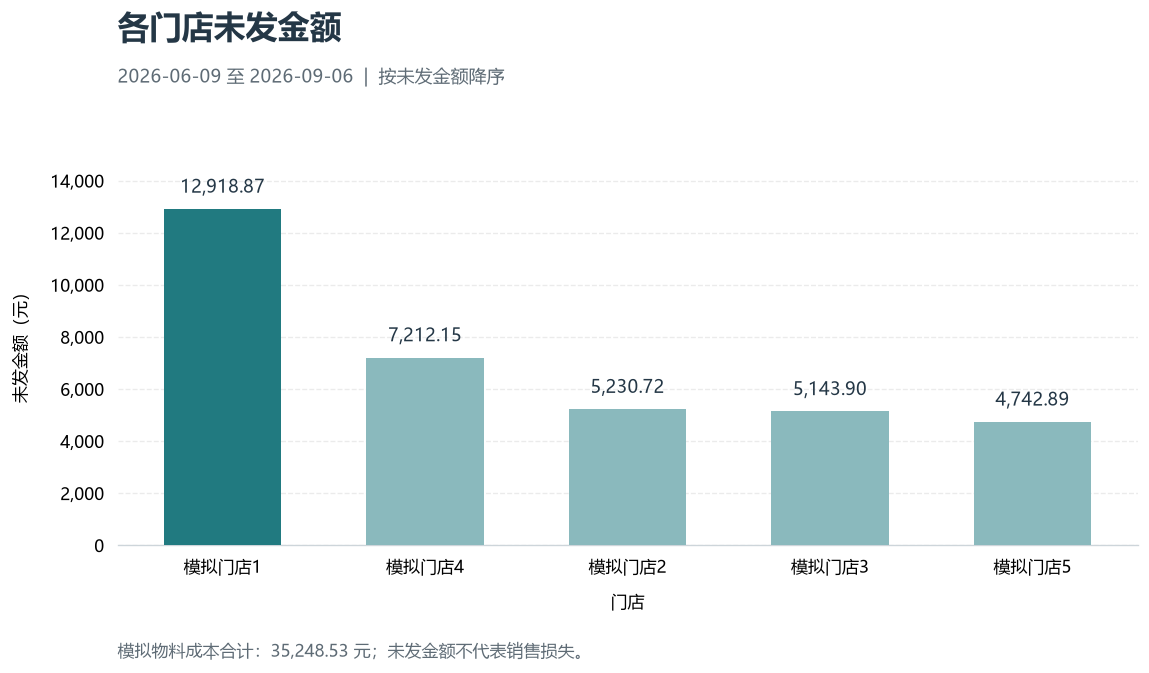

In [4]:
font_path = Path("/mnt/c/Windows/Fonts/msyh.ttc")
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams["axes.unicode_minus"] = False

plot_df = df.sort_values("shortage_amount_cny", ascending=False)
fig_amount, ax = plt.subplots(figsize=(10, 5.8), dpi=120)
fig_amount.subplots_adjust(left=0.12, right=0.97, bottom=0.20, top=0.78)

colors = ["#217A80"] + ["#8AB9BD"] * (len(plot_df) - 1)
bars = ax.bar(plot_df["store_name"], plot_df["shortage_amount_cny"],
              width=0.58, color=colors, zorder=3)
ax.bar_label(bars, labels=[f"{v:,.2f}" for v in plot_df["shortage_amount_cny"]],
             padding=7, fontsize=11, color="#243746")
ax.set_ylim(0, max(float(plot_df["shortage_amount_cny"].max()) * 1.20, 1))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("未发金额（元）", labelpad=12)
ax.set_xlabel("门店", labelpad=10)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#CDD5DA")
ax.tick_params(axis="both", length=0, labelsize=10, pad=8)

fig_amount.text(0.12, 0.93, "各门店未发金额", fontsize=19, weight="bold", color="#243746")
fig_amount.text(0.12, 0.865,
                "2026-06-09 至 2026-09-06  |  按未发金额降序",
                fontsize=11, color="#5E6B75")
fig_amount.text(0.12, 0.04,
                f"模拟物料成本合计：{plot_df['shortage_amount_cny'].sum():,.2f} 元；未发金额不代表销售损失。",
                fontsize=10, color="#5E6B75")
plt.show()


## 4. 门店按时足量率

横向点图采用标明范围的局部百分比坐标，参考线直接标注整体值；同步展示最大差距。

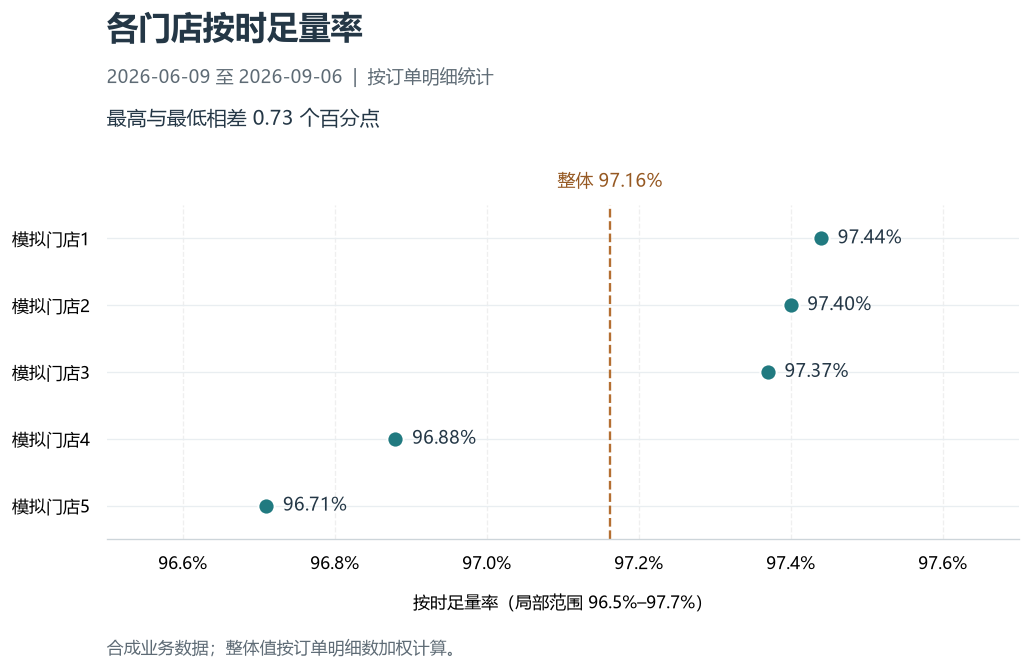

In [5]:
rate_df = df.sort_values('on_time_in_full_pct', ascending=False)
overall_rate = total_on_time / total_lines * 100
spread = rate_df['on_time_in_full_pct'].max() - rate_df['on_time_in_full_pct'].min()
fig_rate, ax_rate = plt.subplots(figsize=(10, 5.8), dpi=120)
fig_rate.subplots_adjust(left=0.18, right=0.94, bottom=0.22, top=0.70)

positions = list(range(len(rate_df)))
ax_rate.scatter(rate_df['on_time_in_full_pct'], positions,
                s=95, color='#217A80', edgecolors='white', linewidths=1.2, zorder=4)
for y, value in zip(positions, rate_df['on_time_in_full_pct']):
    ax_rate.annotate(f'{value:.2f}%', (value, y), xytext=(10, 0),
                     textcoords='offset points', va='center', fontsize=11, color='#243746')
ax_rate.set_yticks(positions, rate_df['store_name'])
ax_rate.set_ylim(len(rate_df) - 0.5, -0.5)
# 点图使用明确标注的局部坐标，避免以截断柱长暗示差距。
ax_rate.set_xlim(96.5, 97.7)
ax_rate.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_rate.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=1))
ax_rate.axvline(overall_rate, color='#B46F32', linestyle='--', linewidth=1.4, zorder=2)
ax_rate.text(overall_rate, 1.04, f'整体 {overall_rate:.2f}%',
             transform=ax_rate.get_xaxis_transform(), ha='center', va='bottom',
             fontsize=11, color='#965923')
ax_rate.set_xlabel('按时足量率（局部范围 96.5%–97.7%）', labelpad=12)
ax_rate.set_axisbelow(True)
ax_rate.grid(axis='x', linestyle='--', alpha=0.20)
ax_rate.grid(axis='y', color='#E9EEF1', linewidth=0.8)
ax_rate.spines[['top', 'right', 'left']].set_visible(False)
ax_rate.spines['bottom'].set_color('#CDD5DA')
ax_rate.tick_params(axis='both', length=0, pad=10)

fig_rate.text(0.18, 0.94, '各门店按时足量率', fontsize=19, weight='bold', color='#243746')
fig_rate.text(0.18, 0.875, '2026-06-09 至 2026-09-06  |  按订单明细统计', fontsize=11, color='#5E6B75')
fig_rate.text(0.18, 0.815, f'最高与最低相差 {spread:.2f} 个百分点', fontsize=12, color='#243746')
fig_rate.text(0.18, 0.055, '合成业务数据；整体值按订单明细数加权计算。', fontsize=10, color='#5E6B75')
plt.show()


## 5. 分析结论与业务建议

### 分析结论

1. **整体履约：** 4,264 条订单明细中，4,143 条按时足量，整体按时足量率 **97.16%**；121 条未足量，占 **2.84%**。未发金额合计 **35,248.53 元**（模拟成本）。
2. **金额优先级：** S1 未发金额 **12,918.87 元**，占总额 **36.65%**，居首；其未足量明细为 22 条，占该店明细 **2.56%**。金额集中度和发生比例的排序不同，不能仅按缺口条数安排核查。
3. **频次优先级：** S5 未足量明细 **28 条**，占 **3.29%**，按时足量率 **96.71%**，为五店最低；S4 未足量 26 条、未发金额 **7,212.15 元**，需要同步关注。

### 业务建议

1. **优先核查 S1 的大金额未发明细。** 按 SKU、订货日期、未发数量和单位成本拆解，并对照订单时点的可用库存、采购到货及冻结/过期状态；确认属于大额需求、库存不可用还是补货不足后，再调整采购与库存参数。
2. **跟踪 S5、S4 的重复未足量需求。** 按日期和 SKU 查找持续缺口，核查补货周期以及按门店编号顺序分配库存的影响；以同一批订单和可用库存比较分配方案，再决定是否调整发货优先级。

### 解释边界

本数据没有超时发货，未按时足量均由未发货或部分发货构成。缺口不能直接归因于人员表现，也不能证明真实配送时效问题。以上建议尚未实施，未发金额不代表销售损失，未量化实际降本效果。

## 6. 结果导出与校验

输出门店汇总 CSV、整体汇总 CSV、两张 PNG 图和检查记录。相同输入重复运行覆盖同名产物，不累加记录。

In [6]:
report_dir = ROOT / 'reports'
figure_dir = report_dir / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

assert len(df) == 5
assert total_lines == 4264 and total_on_time == 4143
assert df['shortage_line_count'].sum() == 121
assert abs(total_shortage_amount - 35248.53) < 0.01
assert abs(df['shortage_amount_pct'].sum() - 100) < 1e-8

store_summary.to_csv(report_dir / 'store_fulfillment_summary.csv', index=False, encoding='utf-8-sig', float_format='%.6f')
overall_summary.to_csv(report_dir / 'fulfillment_overall.csv', index=False, encoding='utf-8-sig', float_format='%.6f')
fig_amount.savefig(figure_dir / 'store_shortage_amount.png', dpi=180, bbox_inches='tight', facecolor='white')
fig_rate.savefig(figure_dir / 'store_on_time_in_full_pct.png', dpi=180, bbox_inches='tight', facecolor='white')

saved = pd.read_csv(report_dir / 'store_fulfillment_summary.csv')
pd.testing.assert_frame_equal(saved, store_summary, check_exact=False, atol=1e-6, rtol=1e-6)
check = {'status': 'PASS', 'store_count': len(df), 'order_line_count': int(total_lines),
         'on_time_in_full_count': int(total_on_time), 'shortage_line_count': 121,
         'shortage_amount_cny': round(float(total_shortage_amount), 2),
         'csv_roundtrip': 'PASS', 'database_access': 'read-only'}
(ROOT / 'checks/notebook_validation.json').write_text(json.dumps(check, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
display(pd.DataFrame({'输出文件': [str(p.relative_to(ROOT)) for p in [
    report_dir / 'store_fulfillment_summary.csv', report_dir / 'fulfillment_overall.csv',
    figure_dir / 'store_shortage_amount.png', figure_dir / 'store_on_time_in_full_pct.png']]}))
print('指标校验与 CSV 回读检查通过')

,输出文件
0,reports/store_fulfillment_summary.csv
1,reports/fulfillment_overall.csv
2,reports/figures/store_shortage_amount.png
3,reports/figures/store_on_time_in_full_pct.png


指标校验与 CSV 回读检查通过
